# Transformer Architecture

Introduced in "Attention Is All You Need" (Vaswani et al., 2017). Replaced RNNs for most sequence tasks.

## 1. Motivation: Problems with RNNs
- Sequential computation → cannot parallelize
- Long-range dependencies still difficult despite LSTM
- Fixed-size bottleneck in Seq2Seq

**Transformers** use attention to model all pairwise token relationships in **one step** fully parallelizable.

## 2. Scaled Dot-Product Attention

Given queries $Q$, keys $K$, values $V$ (all of dimension $d_k$, $d_v$):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

- $Q = XW^Q \in \mathbb{R}^{n \times d_k}$: queries (what am I looking for?)
- $K = XW^K \in \mathbb{R}^{n \times d_k}$: keys (what do I contain?)
- $V = XW^V \in \mathbb{R}^{n \times d_v}$: values (what do I return?)

The $\sqrt{d_k}$ scaling prevents dot products from growing too large (which would push softmax into near-zero gradient regions).

**Complexity**: $O(n^2 d)$ quadratic in sequence length $n$.

## 3. Multi-Head Attention

Run $h$ attention heads in parallel, each with different projection matrices:

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$

where $W_i^Q \in \mathbb{R}^{d_{model} \times d_k}$, $W_i^K \in \mathbb{R}^{d_{model} \times d_k}$, $W_i^V \in \mathbb{R}^{d_{model} \times d_v}$, $W^O \in \mathbb{R}^{hd_v \times d_{model}}$.

Typically $d_k = d_v = d_{model}/h$. In the original paper: $d_{model}=512$, $h=8$, $d_k=d_v=64$.

Multiple heads allow attending to **different positions** and **different representation subspaces**.

## 4. Positional Encoding

Transformers have no recurrence → must inject position information:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Added to token embeddings: $x_{input} = \text{Embedding}(token) + PE$

**Learned positional embeddings** (used in BERT, GPT): directly learned $E_{pos} \in \mathbb{R}^{L_{max} \times d_{model}}$.

**RoPE** (Rotary Position Embedding, Su et al. 2021): encodes relative position via rotation matrices. Used in LLaMA, GPT-NeoX.

**ALiBi** (Press et al. 2021): adds linear bias to attention scores based on distance.

## 5. Feed-Forward Network (FFN)

Applied to each position independently:
$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

Inner dimension is typically $4 \times d_{model}$. This is where most parameters live (~2/3 of total).

## 6. Encoder Block

$$x' = \text{LayerNorm}(x + \text{MultiHeadAttn}(x, x, x))$$
$$x'' = \text{LayerNorm}(x' + \text{FFN}(x'))$$

**Pre-LN** (modern): apply LayerNorm before attention (more stable training).

## 7. Decoder Block

Three sub-layers:
1. **Masked self-attention**: each position attends only to previous positions (causal mask)
2. **Cross-attention**: queries from decoder, keys/values from encoder
3. **FFN**

**Causal mask**: set attention scores to $-\infty$ for future positions before softmax.

## 8. Architecture Variants

| Model | Type | Use Case |
|-------|------|----------|
| BERT | Encoder-only | Classification, NER, QA |
| GPT | Decoder-only | Text generation |
| T5, BART | Encoder-Decoder | Translation, summarization |
| ViT | Encoder-only | Image classification |

## 9. Complexity & Efficient Attention

Standard attention: $O(n^2)$ memory and compute.

- **Sparse Attention** (Longformer, BigBird): local window + global tokens
- **Linear Attention** (Performer): approximates softmax attention in $O(n)$
- **FlashAttention** (Dao et al., 2022): IO-aware exact attention, memory-efficient
- **Grouped Query Attention (GQA)**: fewer KV heads for inference efficiency (LLaMA 2, Mistral)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================
# Transformer from Scratch in PyTorch
# ============================================================

class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        # q,k: (B, H, L, d_k)  v: (B, H, L, d_v)
        attn = torch.matmul(q, k.transpose(-2, -1)) / self.temperature  # (B,H,L,L)
        if mask is not None:
            attn = attn.masked_fill(mask == 0, float('-inf'))
        attn = self.dropout(F.softmax(attn, dim=-1))
        output = torch.matmul(attn, v)  # (B, H, L, d_v)
        return output, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(temperature=self.d_k**0.5, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, L, D = x.shape
        return x.view(B, L, self.n_heads, self.d_k).transpose(1, 2)  # (B,H,L,d_k)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        Q = self.split_heads(self.W_Q(q))
        K = self.split_heads(self.W_K(k))
        V = self.split_heads(self.W_V(v))
        out, attn_weights = self.attention(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        return self.W_O(out), attn_weights


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x): return self.net(x)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(n_heads, d_model, dropout)
        self.ffn  = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(n_heads, d_model, dropout)
        self.cross_attn = MultiHeadAttention(n_heads, d_model, dropout)
        self.ffn   = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask=None, src_mask=None):
        attn1, _ = self.self_attn(x, x, x, tgt_mask)          # masked self-attention
        x = self.norm1(x + self.drop(attn1))
        attn2, _ = self.cross_attn(x, enc_out, enc_out, src_mask)  # cross-attention
        x = self.norm2(x + self.drop(attn2))
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x


class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=256, n_heads=8,
                 n_enc=3, n_dec=3, d_ff=512, dropout=0.1, max_len=200):
        super().__init__()
        self.src_embed = nn.Embedding(src_vocab, d_model)
        self.tgt_embed = nn.Embedding(tgt_vocab, d_model)
        self.pe = PositionalEncoding(d_model, max_len, dropout)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_enc)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_dec)])
        self.fc_out = nn.Linear(d_model, tgt_vocab)
        self.scale = math.sqrt(d_model)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_causal_mask(self, sz):
        return torch.tril(torch.ones(sz, sz)).unsqueeze(0).unsqueeze(0)

    def encode(self, src, src_mask=None):
        x = self.pe(self.src_embed(src) * self.scale)
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_out, src_mask=None):
        tgt_mask = self.make_causal_mask(tgt.size(1)).to(tgt.device)
        x = self.pe(self.tgt_embed(tgt) * self.scale)
        for layer in self.dec_layers:
            x = layer(x, enc_out, tgt_mask, src_mask)
        return self.fc_out(x)

    def forward(self, src, tgt, src_mask=None):
        enc = self.encode(src, src_mask)
        return self.decode(tgt, enc, src_mask)


# --- Test ---
model = Transformer(src_vocab=5000, tgt_vocab=5000, d_model=256, n_heads=8)
print(f'Transformer parameters: {sum(p.numel() for p in model.parameters()):,}')

src = torch.randint(1, 5000, (4, 30))   # (batch=4, src_len=30)
tgt = torch.randint(1, 5000, (4, 25))   # (batch=4, tgt_len=25)
out = model(src, tgt)
print(f'Input src: {src.shape}, tgt: {tgt.shape} → Output: {out.shape}')

Transformer parameters: 7,798,664
Input src: torch.Size([4, 30]), tgt: torch.Size([4, 25]) → Output: torch.Size([4, 25, 5000])


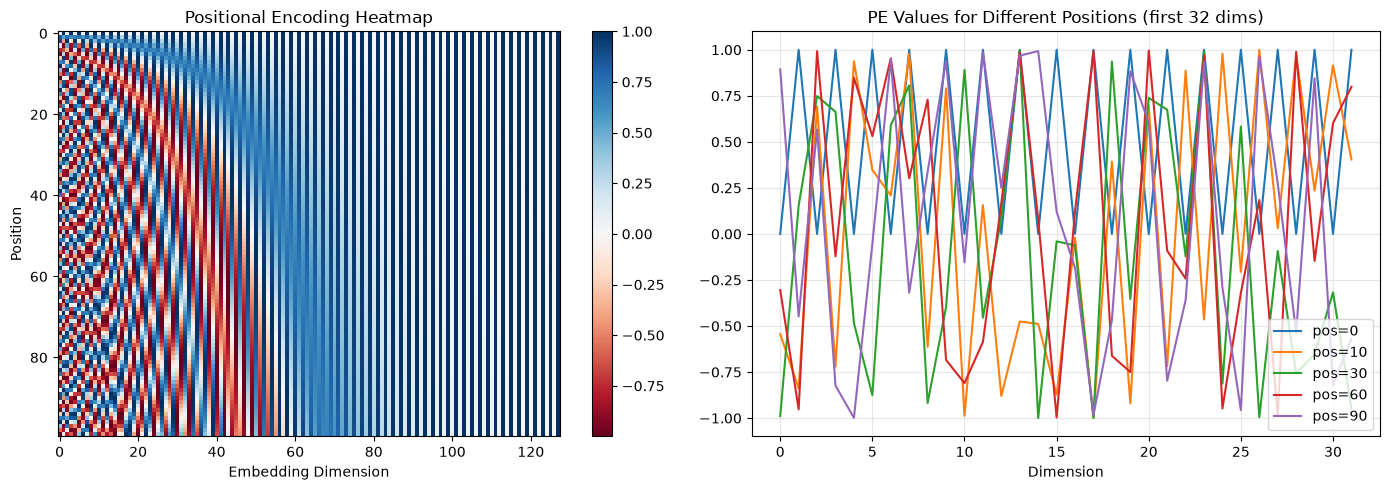

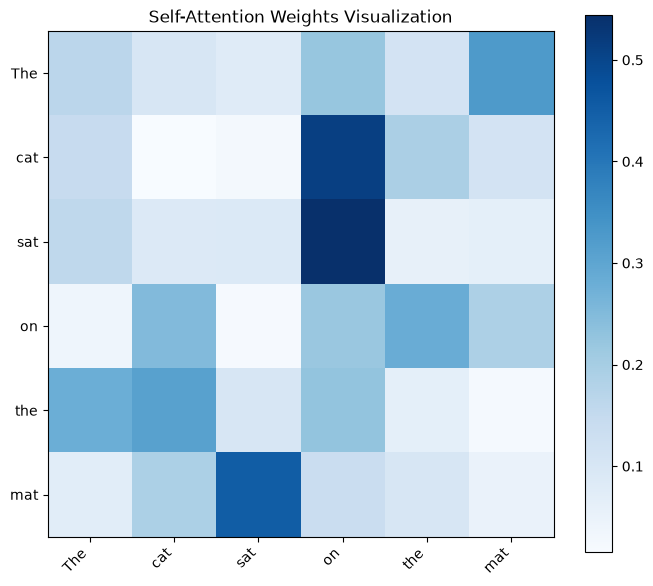

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Visualize Positional Encoding ---
d_model, max_len = 128, 100
pe = np.zeros((max_len, d_model))
positions = np.arange(max_len)[:, np.newaxis]
div_term = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
pe[:, 0::2] = np.sin(positions * div_term)
pe[:, 1::2] = np.cos(positions * div_term)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(pe, cmap='RdBu', aspect='auto')
axes[0].set_title('Positional Encoding Heatmap')
axes[0].set_xlabel('Embedding Dimension'); axes[0].set_ylabel('Position')
plt.colorbar(axes[0].images[0], ax=axes[0])

for pos in [0, 10, 30, 60, 90]:
    axes[1].plot(pe[pos, :32], label=f'pos={pos}')
axes[1].set_title('PE Values for Different Positions (first 32 dims)')
axes[1].set_xlabel('Dimension'); axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Visualize Attention Weights ---
torch.manual_seed(42)
words = ['The', 'cat', 'sat', 'on', 'the', 'mat']
n = len(words)
d_k = 64
Q = torch.randn(1, 1, n, d_k)
K = torch.randn(1, 1, n, d_k)
attn_scores = torch.matmul(Q, K.transpose(-2,-1)) / (d_k**0.5)
attn_weights = F.softmax(attn_scores, dim=-1).squeeze().detach().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(attn_weights, cmap='Blues')
plt.colorbar()
plt.xticks(range(n), words, rotation=45, ha='right')
plt.yticks(range(n), words)
plt.title('Self-Attention Weights Visualization')
plt.tight_layout(); plt.show()

## Additional Learning Resources

### Key Papers
- **Attention Is All You Need** (Vaswani et al., 2017): https://arxiv.org/abs/1706.03762
- **BERT** (Devlin et al., 2018): https://arxiv.org/abs/1810.04805
- **GPT-3** (Brown et al., 2020): https://arxiv.org/abs/2005.14165
- **RoPE** (Su et al., 2021): https://arxiv.org/abs/2104.09864
- **FlashAttention** (Dao et al., 2022): https://arxiv.org/abs/2205.14135
- **FlashAttention-2** (Dao, 2023): https://arxiv.org/abs/2307.08691
- **GQA** (Ainslie et al., 2023): https://arxiv.org/abs/2305.13245

### Best Explanations
- **The Illustrated Transformer** Jay Alammar: https://jalammar.github.io/illustrated-transformer/
- **The Annotated Transformer** Harvard NLP: https://nlp.seas.harvard.edu/annotated-transformer/
- **Let's Build GPT from Scratch** Karpathy: https://www.youtube.com/watch?v=kCc8FmEb1nY
- **Transformer Circuits** Anthropic: https://transformer-circuits.pub/

### Courses
- **Stanford CS224n**: https://web.stanford.edu/class/cs224n/
- **Hugging Face NLP Course**: https://huggingface.co/learn/nlp-course
- **LLM University Cohere**: https://cohere.com/llmu